# Othello baseline vs assisted — results

Compares `game_user_study_baseline_othello` (all three rounds unassisted) against
`game_user_study_phase_othello` (R1 AI-assisted, R2+R3 unassisted transfer block).

**Rounds.** R1 = `oc20260727` (assisted in the phase arm), then the transfer block:
R2 = `b220260706`, R3 = `bg20260726`. R2 carries `survey: False`, so **NASA-TLX exists
for R1 and R3 only**.

**Read the caveats before quoting anything.**

1. **R1 is confounded.** The R1 time limit differs by arm (baseline 300 s, phase 480 s),
   and the phase arm's mandated 5+ assistant turns means it spends far longer on task.
   R1 differences are "AI *plus* time-on-task", not an assistance effect. The transfer
   block is clean — 90 s per puzzle in both arms.
2. **The transfer block is barely engaged.** Medians run ~8–11 s against a 90 s budget in
   both arms. A null there may mean transfer was not *expressed*, not that it did not occur.
3. **Reliability is low.** R2↔R3 parallel-forms reliability is ~0.22–0.30 depending on
   metric, so individual-difference claims are weak regardless of sample size. The
   between-arm group contrast is fine — noise costs power, not unbiasedness.
4. **Pre-specify the primary metric.** The four transfer metrics have disagreed in
   direction at small n. Pick one before the sample grows.

Estimates are reported as **difference + bootstrap CI** first, with p-values secondary.

In [459]:
from pathlib import Path
import json, re, warnings
from collections import Counter, defaultdict

import numpy as np
from scipy.stats import mannwhitneyu, chi2_contingency

warnings.filterwarnings("ignore")
rng = np.random.default_rng(7)

BASE = Path("/Users/siyanli/Documents/CITRUS")
ARMS = {
    "baseline": BASE / "game_user_study_baseline_othello",
    "phase":    BASE / "game_user_study_phase_othello",
}
HEX = re.compile(r"^[0-9a-f]{24}$")          # real prolific ids; drops test accounts

R1, R2, R3 = "oc20260727", "b220260706", "bg20260726"
TLX_ROUNDS = [(R1, "R1"), (R3, "R3")]        # R2 has survey=False
TLX_DIMS = ["mental_demand", "temporal_demand", "performance", "effort", "frustration"]
TLX_MIN, TLX_MAX = 1, 7                      # performance reverse-scores as (TLX_MAX+1) - x

# Ratio metrics are DERIVED per round as numerator/denominator, and pooled across rounds
# as sum(numerator)/sum(denominator) -- never summed or averaged. Two reasons:
#   * scores.csv's `transfer_*` columns (incl. transfer_rate) are participant-level: the
#     R2+R3 pooled value is written onto every round's row, so reading them per round
#     gives the same number back twice. Derive the rate from score/decisions instead.
#   * the puzzles offer a different number of Black decisions (2 or 3), so pooling by
#     decision is the weighting score_from_logs.py already uses for transfer_rate.
RATIOS = {
    "optimal_rate":           ("score", "decisions"),
    "disc_loss_per_decision": ("disc_loss_total", "decisions"),
}

# Transfer metrics, and which direction is better. Set PRIMARY before the sample grows.
METRICS = [
    ("optimal_rate",           "optimal-move rate",    "higher"),
    ("disc_loss_total",        "disc loss (total)",    "lower"),
    ("disc_loss_per_decision", "disc loss / decision", "lower"),
    ("margin",                 "final margin",         "higher"),
]
PRIMARY = "optimal_rate"           # best resolution x reliability tradeoff

In [460]:
def _num(x):
    try:
        return float(x)
    except (TypeError, ValueError):
        return None


def load_scores(arm_dir):
    """scores.csv -> {pid: {round_label: row}}. Produced by score_from_logs.py."""
    import csv
    f = arm_dir / "scores.csv"
    if not f.exists():
        print(f"!! {f} missing — run `python score_from_logs.py` in {arm_dir.name}")
        return {}
    by = defaultdict(dict)
    for row in csv.DictReader(open(f)):
        by[row["pid"]][row["round"]] = row
    return by


def load_participants(arm_dir):
    """Per-participant JSON the scores.csv does not carry (TLX, demographics, gate)."""
    root = arm_dir / "recordings-download"
    out = {}
    for d in sorted(p for p in root.iterdir() if p.is_dir()):
        if not HEX.match(d.name):
            continue
        rec = {"pid": d.name, "dir": d}
        rec["demographics"] = _readj(d / "demographics.json")
        rec["gate"] = _readj(d / f"gate_p{R1}.json")
        for puzzle, label in TLX_ROUNDS:
            s = _readj(d / f"post_survey_p{puzzle}.json")
            rec[f"tlx_{label}"] = (s or {}).get("nasa_tlx")
        out[d.name] = rec
    return out


def _readj(p):
    if not p.exists():
        return None
    try:
        return json.load(open(p))
    except Exception:
        return None


SCORES = {k: load_scores(v) for k, v in ARMS.items()}
PEOPLE = {k: load_participants(v) for k, v in ARMS.items()}
for arm in ARMS:
    print(f"{arm:9s} recordings dirs={len(PEOPLE[arm]):3d}  scored pids={len(SCORES[arm]):3d}")

baseline  recordings dirs=132  scored pids=102
phase     recordings dirs=149  scored pids=125


## Population and completeness

`analysis set` = has both transfer rounds scored. That is the population every
transfer comparison below runs on.

In [461]:
def analysis_set(arm):
    """pids with both transfer rounds present in scores.csv."""
    return [p for p, d in SCORES[arm].items() if R2_L in d and R3_L in d]


R1_L, R2_L, R3_L = "R1", "R2", "R3"

for arm in ARMS:
    s = SCORES[arm]
    have = Counter()
    for p, d in s.items():
        for lab in (R1_L, R2_L, R3_L):
            have[lab] += lab in d
    n_an = len(analysis_set(arm))
    print(f"{arm:9s} n={len(s):3d} | R1={have[R1_L]:3d} R2={have[R2_L]:3d} R3={have[R3_L]:3d} "
          f"| analysis set (R2+R3) = {n_an}")

ASET = {arm: analysis_set(arm) for arm in ARMS}
if min(len(v) for v in ASET.values()) < 15:
    print("\n** WARNING: an arm has n < 15. Treat everything below as descriptive. **")

baseline  n=102 | R1=102 R2=100 R3=100 | analysis set (R2+R3) = 100
phase     n=125 | R1=124 R2=111 R3=112 | analysis set (R2+R3) = 111


## Comparison helpers

`compare` reports the difference (phase − baseline) with a bootstrap percentile CI,
the rank-biserial effect size, and Mann–Whitney p. It refuses to run below `min_n`
so small-sample noise is not reported as a result.

In [462]:
def boot_diff(a, b, nb=10000):
    a, b = np.asarray(a, float), np.asarray(b, float)
    out = np.empty(nb)
    for i in range(nb):
        out[i] = b[rng.integers(0, len(b), len(b))].mean() - a[rng.integers(0, len(a), len(a))].mean()
    return np.percentile(out, [2.5, 97.5])


def compare(a, b, label, unit="", min_n=8, la="base", lb="phase"):
    """b - a, with CI. Returns None (and says so) when either arm is too small."""
    a = [x for x in a if x is not None]
    b = [x for x in b if x is not None]
    if len(a) < min_n or len(b) < min_n:
        print(f"  {label:26s} n={len(a)}/{len(b)}  -- too small for inference; "
              f"{la} mean={np.mean(a) if a else float('nan'):.2f} {lb} mean={np.mean(b) if b else float('nan'):.2f}")
        return None
    A, B = np.asarray(a, float), np.asarray(b, float)
    U, p = mannwhitneyu(A, B, alternative="two-sided")
    rbc = 1 - 2 * U / (len(A) * len(B))
    lo, hi = boot_diff(A, B)
    md_ = B.mean() - A.mean()
    star = " *" if p < 0.05 else ""
    print(f"  {label:26s} n={len(A):3d}/{len(B):3d} {la}={A.mean():6.2f} {lb}={B.mean():6.2f} "
          f"diff={md_:+7.3f}{unit} [{lo:+.2f},{hi:+.2f}] rbc={rbc:+.2f} p={p:.3f}{star}")
    return {"diff": md_, "ci": (lo, hi), "rbc": rbc, "p": p, "n": (len(A), len(B))}


def describe(vals, label):
    v = np.asarray([x for x in vals if x is not None], float)
    if not len(v):
        print(f"  {label:26s} (no data)")
        return
    print(f"  {label:26s} n={len(v):3d} mean={v.mean():6.2f} med={np.median(v):6.2f} "
          f"sd={v.std(ddof=1) if len(v) > 1 else 0:5.2f} range=[{v.min():.1f},{v.max():.1f}]")

## NASA-TLX

Scale is **1–7, Low → High** on every item. `performance` is worded *"how successful were
you"*, so higher means the participant felt they did better — it is **reverse-scored**
(`8 − performance`) in the overall workload index and **not** reversed in its own row.

TLX is available for **R1** (assisted in the phase arm) and **R3** (unassisted in both).
R3 is the interesting one: it is the clean comparison, since both arms are unassisted
and under the same 90 s limit.

In [463]:
def tlx_values(arm, round_label, dim, restrict_to_analysis_set=True):
    pids = ASET[arm] if restrict_to_analysis_set else list(PEOPLE[arm])
    out = []
    for p in pids:
        t = (PEOPLE[arm].get(p) or {}).get(f"tlx_{round_label}")
        if not t:
            continue
        if dim == "overall":
            if any(t.get(d) is None for d in TLX_DIMS):
                continue
            out.append(np.mean([t["mental_demand"], t["temporal_demand"],
                                (TLX_MAX + 1) - t["performance"], t["effort"], t["frustration"]]))
        elif t.get(dim) is not None:
            out.append(float(t[dim]))
    return out


for _, lab in TLX_ROUNDS:
    note = "assisted in phase arm - CONFOUNDED by time-on-task" if lab == "R1" else "unassisted both arms - clean"
    print(f"\n=== NASA-TLX {lab}  ({note}) ===")
    for dim in TLX_DIMS + ["overall"]:
        compare(tlx_values("baseline", lab, dim), tlx_values("phase", lab, dim), dim)


=== NASA-TLX R1  (assisted in phase arm - CONFOUNDED by time-on-task) ===
  mental_demand              n=100/110 base=  4.94 phase=  5.09 diff= +0.151 [-0.23,+0.52] rbc=+0.09 p=0.228
  temporal_demand            n=100/110 base=  3.47 phase=  3.85 diff= +0.375 [-0.11,+0.87] rbc=+0.12 p=0.133
  performance                n=100/110 base=  2.01 phase=  3.13 diff= +1.117 [+0.66,+1.57] rbc=+0.34 p=0.000 *
  effort                     n=100/110 base=  4.31 phase=  4.65 diff= +0.345 [-0.04,+0.73] rbc=+0.15 p=0.051
  frustration                n=100/110 base=  4.16 phase=  4.35 diff= +0.195 [-0.27,+0.65] rbc=+0.07 p=0.409
  overall                    n=100/110 base=  4.57 phase=  4.56 diff= -0.010 [-0.30,+0.27] rbc=+0.03 p=0.698

=== NASA-TLX R3  (unassisted both arms - clean) ===
  mental_demand              n=100/110 base=  4.89 phase=  5.12 diff= +0.228 [-0.13,+0.58] rbc=+0.08 p=0.288
  temporal_demand            n=100/110 base=  4.28 phase=  3.82 diff= -0.462 [-0.99,+0.08] rbc=-0.13 p=0.09

In [464]:
# Per-arm TLX distributions (works at any n, unlike the comparisons above)
for _, lab in TLX_ROUNDS:
    print(f"\n=== TLX {lab} distributions ===")
    for arm in ARMS:
        print(f" {arm}")
        for dim in TLX_DIMS + ["overall"]:
            describe(tlx_values(arm, lab, dim), dim)


=== TLX R1 distributions ===
 baseline
  mental_demand              n=100 mean=  4.94 med=  5.00 sd= 1.30 range=[2.0,7.0]
  temporal_demand            n=100 mean=  3.47 med=  3.00 sd= 1.76 range=[1.0,7.0]
  performance                n=100 mean=  2.01 med=  2.00 sd= 1.34 range=[1.0,6.0]
  effort                     n=100 mean=  4.31 med=  5.00 sd= 1.30 range=[1.0,7.0]
  frustration                n=100 mean=  4.16 med=  4.00 sd= 1.69 range=[1.0,7.0]
  overall                    n=100 mean=  4.57 med=  4.60 sd= 0.93 range=[2.2,6.6]
 phase
  mental_demand              n=110 mean=  5.09 med=  5.00 sd= 1.49 range=[1.0,7.0]
  temporal_demand            n=110 mean=  3.85 med=  4.00 sd= 1.86 range=[1.0,7.0]
  performance                n=110 mean=  3.13 med=  2.50 sd= 1.97 range=[1.0,7.0]
  effort                     n=110 mean=  4.65 med=  5.00 sd= 1.57 range=[1.0,7.0]
  frustration                n=110 mean=  4.35 med=  4.50 sd= 1.74 range=[1.0,7.0]
  overall                    n=110 mean=

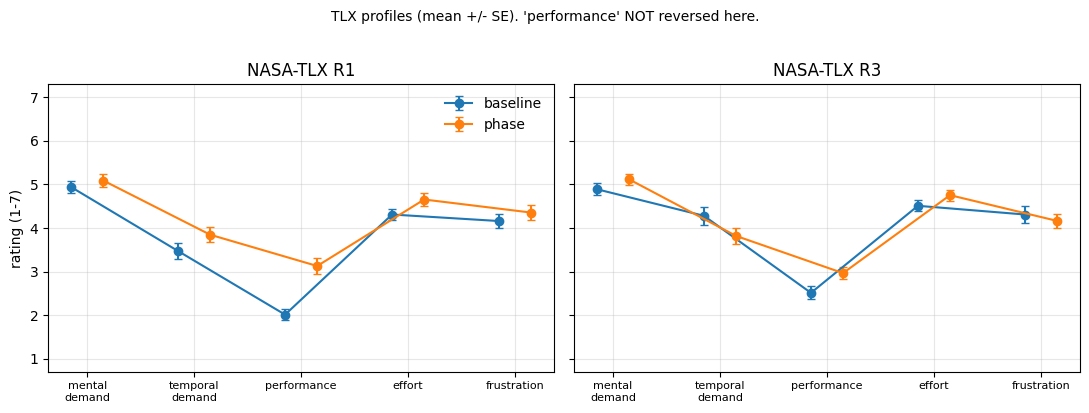

In [465]:
# TLX profile plot. Skips cleanly if matplotlib is unavailable in this kernel.
try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, len(TLX_ROUNDS), figsize=(11, 4), sharey=True)
    axes = np.atleast_1d(axes)
    x = np.arange(len(TLX_DIMS))
    for ax, (_, lab) in zip(axes, TLX_ROUNDS):
        for arm, off in zip(ARMS, (-0.15, 0.15)):
            m = [np.mean(tlx_values(arm, lab, d)) if tlx_values(arm, lab, d) else np.nan
                 for d in TLX_DIMS]
            se = [np.std(tlx_values(arm, lab, d), ddof=1) / max(np.sqrt(len(tlx_values(arm, lab, d))), 1)
                  if len(tlx_values(arm, lab, d)) > 1 else 0 for d in TLX_DIMS]
            ax.errorbar(x + off, m, yerr=se, fmt="o-", capsize=3, label=arm)
        ax.set_xticks(x)
        ax.set_xticklabels([d.replace("_", "\n") for d in TLX_DIMS], fontsize=8)
        ax.set_title(f"NASA-TLX {lab}")
        ax.set_ylim(TLX_MIN - 0.3, TLX_MAX + 0.3)
        ax.grid(alpha=0.3)
    axes[0].set_ylabel("rating (1-7)")
    axes[0].legend(frameon=False)
    fig.suptitle("TLX profiles (mean +/- SE). 'performance' NOT reversed here.", y=1.02, fontsize=10)
    plt.tight_layout()
    plt.show()
except ImportError:
    print("matplotlib unavailable in this kernel - skipping plot")

## Transfer block (R2 + R3 pooled) — the primary outcome

Both arms unassisted, same puzzles, same 90 s limit. This is the clean contrast.

All four metrics are shown because they have disagreed in direction at small n. Decide
`PRIMARY` before the sample grows, and report the rest as sensitivity.

In [466]:
def round_value(arm, pid, rl, key):
    """One round's value for one participant. Ratio metrics are derived from their
    numerator/denominator columns -- never read off a `transfer_*` column, which is
    participant-level and would return the same pooled number for every round."""
    d = SCORES[arm].get(pid, {})
    if rl not in d:
        return None
    if key in RATIOS:
        nk, dk = RATIOS[key]
        n, den = _num(d[rl].get(nk)), _num(d[rl].get(dk))
        return n / den if n is not None and den else None
    return _num(d[rl].get(key))


def block_value(arm, pid, key):
    """R2 + R3 pooled for one participant, or None if either round is missing.
    Counts sum; ratios pool as sum(numerator)/sum(denominator)."""
    d = SCORES[arm].get(pid, {})
    if not all(r in d for r in (R2_L, R3_L)):
        return None
    if key in RATIOS:
        nk, dk = RATIOS[key]
        nums = [_num(d[r].get(nk)) for r in (R2_L, R3_L)]
        dens = [_num(d[r].get(dk)) for r in (R2_L, R3_L)]
        if None in nums or None in dens or not sum(dens):
            return None
        return sum(nums) / sum(dens)
    vals = [_num(d[r].get(key)) for r in (R2_L, R3_L)]
    return sum(vals) if None not in vals else None


def block_values(arm, key):
    return [block_value(arm, p, key) for p in ASET[arm]]


# Sanity check: the derived pooled rate must reproduce score_from_logs.py's transfer_rate.
_bad = [(arm, p) for arm in ARMS for p in ASET[arm]
        if _num(SCORES[arm][p][R2_L].get("transfer_rate")) is not None
        and abs(block_value(arm, p, "optimal_rate")
                - _num(SCORES[arm][p][R2_L]["transfer_rate"])) > 5e-4]
print(f"optimal_rate vs scores.csv transfer_rate: {len(_bad)} mismatches "
      f"(expect 0; transfer_rate is rounded to 3 dp)\n")

print("=== Transfer block, phase - baseline ===")
for key, lab, better in METRICS:
    mark = "  <-- PRIMARY" if key == PRIMARY else ""
    print(f"\n {lab}  ({better}=better){mark}")
    for arm in ARMS:
        describe(block_values(arm, key), arm)
    compare(block_values("baseline", key), block_values("phase", key), "difference")

optimal_rate vs scores.csv transfer_rate: 0 mismatches (expect 0; transfer_rate is rounded to 3 dp)

=== Transfer block, phase - baseline ===

 optimal-move rate  (higher=better)  <-- PRIMARY
  baseline                   n=100 mean=  0.42 med=  0.45 sd= 0.26 range=[0.0,1.0]
  phase                      n=111 mean=  0.46 med=  0.50 sd= 0.26 range=[0.0,1.0]
  difference                 n=100/111 base=  0.42 phase=  0.46 diff= +0.041 [-0.03,+0.11] rbc=+0.09 p=0.256

 disc loss (total)  (lower=better)
  baseline                   n=100 mean= 31.30 med= 31.00 sd=12.49 range=[0.0,56.0]
  phase                      n=111 mean= 29.48 med= 30.00 sd=11.67 range=[0.0,60.0]
  difference                 n=100/111 base= 31.30 phase= 29.48 diff= -1.823 [-5.06,+1.46] rbc=-0.08 p=0.335

 disc loss / decision  (lower=better)
  baseline                   n=100 mean=  7.12 med=  6.90 sd= 3.31 range=[0.0,14.0]
  phase                      n=111 mean=  6.52 med=  6.00 sd= 3.00 range=[0.0,12.5]
  difference 

In [467]:
# R2 and R3 separately -- and the parallel-forms reliability that limits everything.
from scipy.stats import pearsonr

print("=== Transfer rounds separately ===")
for key, lab, better in METRICS:
    print(f"\n {lab} ({better}=better)")
    for rl in (R2_L, R3_L):
        a = [round_value("baseline", p, rl, key) for p in ASET["baseline"]]
        b = [round_value("phase", p, rl, key) for p in ASET["phase"]]
        compare(a, b, f"  {rl}")

print("\n=== Parallel-forms reliability (R2 vs R3), pooled across arms ===")
print("    Spearman-Brown gives the reliability of the R2+R3 pooled outcome above.")
for key, lab, _ in METRICS:
    xy = []
    for arm in ARMS:
        for p in ASET[arm]:
            x, y = round_value(arm, p, R2_L, key), round_value(arm, p, R3_L, key)
            if x is not None and y is not None:
                xy.append((x, y))
    if len(xy) < 10:
        print(f"  {lab:22s} n={len(xy)} too small")
        continue
    x = np.array([t[0] for t in xy]); y = np.array([t[1] for t in xy])
    r, p = pearsonr(x, y)
    sb = 2 * r / (1 + r) if r > -1 else np.nan
    print(f"  {lab:22s} n={len(xy):3d}  r={r:+.3f} (p={p:.3f})  Spearman-Brown={sb:+.3f}")

=== Transfer rounds separately ===

 optimal-move rate (higher=better)
    R2                       n=100/111 base=  0.47 phase=  0.46 diff= -0.012 [-0.09,+0.07] rbc=-0.01 p=0.856
    R3                       n=100/111 base=  0.35 phase=  0.44 diff= +0.088 [-0.00,+0.18] rbc=+0.13 p=0.089

 disc loss (total) (lower=better)
    R2                       n=100/111 base= 15.36 phase= 15.17 diff= -0.189 [-2.14,+1.83] rbc=-0.03 p=0.698
    R3                       n=100/111 base= 15.94 phase= 14.31 diff= -1.634 [-3.87,+0.54] rbc=-0.11 p=0.179

 disc loss / decision (lower=better)
    R2                       n=100/111 base=  7.33 phase=  7.29 diff= -0.042 [-1.06,+0.99] rbc=-0.01 p=0.859
    R3                       n=100/111 base=  7.21 phase=  6.15 diff= -1.060 [-2.14,+0.03] rbc=-0.12 p=0.121

 final margin (higher=better)
    R2                       n=100/108 base= -3.36 phase= -3.20 diff= +0.156 [-1.76,+2.10] rbc=+0.02 p=0.808
    R3                       n=100/111 base=-11.94 phase=-10.3

## R1 — read with the confound in mind

The phase arm had the assistant **and** a longer limit (480 s vs 300 s) **and** a mandated
5+ turns, so it spends far longer on task. Any R1 gap is assistance *plus* time-on-task.
Useful as a manipulation check; not quotable as an assistance effect.

In [468]:
print("=== R1 (CONFOUNDED: 300s vs 480s limit, plus mandated 5+ assistant turns) ===")
for key, lab, better in METRICS + [("seconds", "seconds on task", "n/a"),
                                   ("decisions", "decisions made", "n/a")]:
    a = [round_value("baseline", p, R1_L, key) for p in ASET["baseline"]]
    b = [round_value("phase", p, R1_L, key) for p in ASET["phase"]]
    compare(a, b, f"{lab} ({better})")

=== R1 (CONFOUNDED: 300s vs 480s limit, plus mandated 5+ assistant turns) ===
  optimal-move rate (higher) n=100/110 base=  0.43 phase=  0.70 diff= +0.266 [+0.20,+0.33] rbc=+0.56 p=0.000 *
  disc loss (total) (lower)  n=100/110 base= 38.96 phase= 24.60 diff=-14.360 [-17.91,-10.69] rbc=-0.55 p=0.000 *
  disc loss / decision (lower) n=100/110 base= 11.02 phase=  6.58 diff= -4.440 [-5.66,-3.26] rbc=-0.50 p=0.000 *
  final margin (higher)      n=100/101 base=-20.96 phase= -8.20 diff=+12.762 [+9.18,+16.42] rbc=+0.52 p=0.000 *
  seconds on task (n/a)      n=100/110 base= 31.99 phase=161.30 diff=+129.310 [+108.09,+151.50] rbc=+0.73 p=0.000 *
  decisions made (n/a)       n=100/110 base=  3.75 phase=  4.33 diff= +0.577 [+0.32,+0.84] rbc=+0.30 p=0.000 *


## Engagement — is the transfer block actually being attempted?

Both arms get 90 s per transfer puzzle. If medians sit near 10 s, a null on the transfer
block cannot distinguish "no transfer occurred" from "no transfer was expressed". Track
this as sample size grows, and consider it a design signal rather than a result.

In [469]:
LIMITS = {R1_L: None, R2_L: 90, R3_L: 90}   # R1 limit differs by arm; see caveat above
R1_LIMIT = {"baseline": 300, "phase": 480}

print("=== Seconds on task per round ===")
for rl in (R1_L, R2_L, R3_L):
    print(f"\n {rl}  (limit: {LIMITS[rl] if LIMITS[rl] else 'differs by arm'})")
    for arm in ARMS:
        s = [_num(SCORES[arm][p][rl].get("seconds")) for p in ASET[arm] if rl in SCORES[arm][p]]
        s = np.array([x for x in s if x is not None], float)
        if not len(s):
            continue
        lim = LIMITS[rl] or R1_LIMIT[arm]
        print(f"   {arm:9s} n={len(s):3d} median={np.median(s):6.1f}s max={s.max():6.1f}s "
              f"| {np.median(s)/lim*100:4.1f}% of the {lim}s budget | at cap: {(s >= lim*0.98).sum()}")

print("\n=== Assistant turns (phase arm only; mandate is 5+) ===")
t = [_num(SCORES["phase"][p][R1_L].get("ai_turns")) for p in ASET["phase"] if R1_L in SCORES["phase"][p]]
t = [x for x in t if x is not None]
if t:
    c = Counter(int(x) for x in t)
    print(f"   {dict(sorted(c.items()))}")
    print(f"   exactly 5 (the floor): {c[5]}/{len(t)} = {c[5]/len(t)*100:.0f}%  "
          "-- a floor treated as a ceiling means engagement was complied with, not induced")

=== Seconds on task per round ===

 R1  (limit: differs by arm)
   baseline  n=100 median=  26.0s max= 112.0s |  8.7% of the 300s budget | at cap: 0
   phase     n=110 median= 152.5s max= 456.0s | 31.8% of the 480s budget | at cap: 0

 R2  (limit: 90)
   baseline  n=100 median=   9.0s max=  62.0s | 10.0% of the 90s budget | at cap: 0
   phase     n=111 median=  10.0s max=  49.0s | 11.1% of the 90s budget | at cap: 0

 R3  (limit: 90)
   baseline  n=100 median=   8.0s max=  52.0s |  8.9% of the 90s budget | at cap: 0
   phase     n=111 median=  12.0s max=  66.0s | 13.3% of the 90s budget | at cap: 0

=== Assistant turns (phase arm only; mandate is 5+) ===
   {3: 3, 4: 2, 5: 74, 6: 15, 7: 6, 8: 4, 9: 4, 10: 2}
   exactly 5 (the floor): 74/110 = 67%  -- a floor treated as a ceiling means engagement was complied with, not induced


## Pre-assistance ability probe (gate)

The unaided first move on R1, recorded **before** the assistant unlocks, in both arms.
This is the one ability measure taken identically across arms prior to treatment — it is
both the balance check and the pre-registerable moderator (it was the sturdiest term in
the Connect Four models).

In [470]:
def gate_correct(arm):
    out = []
    for p in ASET[arm]:
        g = (PEOPLE[arm].get(p) or {}).get("gate")
        if g and g.get("first_move_optimal") is not None:
            out.append(bool(g["first_move_optimal"]))
    return out


print("=== Balance on the pre-assistance probe ===")
gb, gp = gate_correct("baseline"), gate_correct("phase")
for lab, g in [("baseline", gb), ("phase", gp)]:
    if g:
        print(f"  {lab:9s} optimal first move = {sum(g)}/{len(g)} = {sum(g)/len(g)*100:.1f}%")
if len(gb) >= 8 and len(gp) >= 8:
    from scipy.stats import fisher_exact
    _, p = fisher_exact([[sum(gb), len(gb) - sum(gb)], [sum(gp), len(gp) - sum(gp)]])
    print(f"  Fisher exact p={p:.3f}")
else:
    print("  (too small for a balance test)")

print("\n=== Transfer outcome stratified by the probe (the pre-registerable moderator) ===")
for gv, gl in [(True, "probe CORRECT"), (False, "probe WRONG  ")]:
    a = [block_value("baseline", p, PRIMARY) for p in ASET["baseline"]
         if (PEOPLE["baseline"].get(p) or {}).get("gate", {}).get("first_move_optimal") is gv]
    b = [block_value("phase", p, PRIMARY) for p in ASET["phase"]
         if (PEOPLE["phase"].get(p) or {}).get("gate", {}).get("first_move_optimal") is gv]
    compare(a, b, gl)
print(f"  (outcome = {PRIMARY})")

=== Balance on the pre-assistance probe ===
  baseline  optimal first move = 32/100 = 32.0%
  phase     optimal first move = 26/110 = 23.6%
  Fisher exact p=0.217

=== Transfer outcome stratified by the probe (the pre-registerable moderator) ===
  probe CORRECT              n= 32/ 26 base=  0.39 phase=  0.49 diff= +0.106 [-0.02,+0.23] rbc=+0.22 p=0.141
  probe WRONG                n= 68/ 84 base=  0.44 phase=  0.45 diff= +0.013 [-0.07,+0.10] rbc=+0.04 p=0.710
  (outcome = optimal_rate)


## Demographics balance

In [471]:
def demo_num(arm, key):
    out = []
    for p in ASET[arm]:
        d = (PEOPLE[arm].get(p) or {}).get("demographics") or {}
        v = d.get(key)
        if v in (None, ""):
            continue
        try:
            out.append(float(v))
        except (TypeError, ValueError):
            pass                      # e.g. skill_rating == "dont_know"
    return out


def demo_cat(arm, key):
    out = []
    for p in ASET[arm]:
        d = (PEOPLE[arm].get(p) or {}).get("demographics") or {}
        if d.get(key) not in (None, ""):
            out.append(str(d[key]))
    return out


print("=== numeric ===")
for key in ["age", "skill_rating"]:
    compare(demo_num("baseline", key), demo_num("phase", key), key)

print("\n=== categorical ===")
for key in ["education", "occupation", "genai_usage"]:
    ca, cb = demo_cat("baseline", key), demo_cat("phase", key)
    cats = sorted(set(ca) | set(cb))
    ct = np.array([[Counter(ca)[c] for c in cats], [Counter(cb)[c] for c in cats]])
    ct = ct[:, ct.sum(axis=0) > 0]
    if ct.shape[1] < 2 or ct.sum() == 0 or min(len(ca), len(cb)) < 8:
        print(f"  {key:26s} n={len(ca)}/{len(cb)} -- too small / too few categories")
        print(f"    baseline: {dict(Counter(ca))}")
        print(f"    phase:    {dict(Counter(cb))}")
        continue
    chi2, p, dof, exp = chi2_contingency(ct)
    v = np.sqrt(chi2 / (ct.sum() * (min(ct.shape) - 1)))
    warn = "  (min expected < 5: approximate)" if exp.min() < 5 else ""
    print(f"  {key:26s} chi2={chi2:6.2f} dof={dof} p={p:.3f} CramersV={v:.2f}{warn}")

=== numeric ===
  age                        n=100/110 base= 42.28 phase= 43.12 diff= +0.838 [-2.25,+4.00] rbc=+0.04 p=0.617
  skill_rating               n= 70/ 74 base=  1.37 phase=  1.50 diff= +0.129 [-0.08,+0.34] rbc=+0.08 p=0.321

=== categorical ===
  education                  chi2= 10.28 dof=6 p=0.113 CramersV=0.22  (min expected < 5: approximate)
  occupation                 chi2=  8.05 dof=12 p=0.781 CramersV=0.20  (min expected < 5: approximate)
  genai_usage                chi2=  2.83 dof=7 p=0.900 CramersV=0.12  (min expected < 5: approximate)


## Power — what the current n can detect

MDE is for the between-arm transfer contrast at 80% power, two-sided α = 0.05, using the
pooled SD of `PRIMARY`. Use this to decide how many baseline participants to collect.

In [472]:
from scipy.stats import norm

vals = np.array([v for arm in ARMS for v in block_values(arm, PRIMARY) if v is not None], float)
sd = vals.std(ddof=1)
z = norm.ppf(0.975) + norm.ppf(0.80)
n_b, n_p = len(ASET["baseline"]), len(ASET["phase"])

print(f"PRIMARY = {PRIMARY}   pooled sd = {sd:.2f}   current n = {n_b} baseline / {n_p} phase\n")
print(f"  {'baseline n':>12s} {'phase n':>9s} {'MDE (d)':>9s} {'MDE (units)':>12s}")
for nb in [n_b, 25, 50, 75, 100, 150]:
    npz = max(n_p, nb)
    d = z * np.sqrt(1 / nb + 1 / npz)
    print(f"  {nb:12d} {npz:9d} {d:9.2f} {d*sd:12.2f}")
print("\nFor reference, the Connect Four study achieved MDE d = 0.44.")

PRIMARY = optimal_rate   pooled sd = 0.26   current n = 100 baseline / 111 phase

    baseline n   phase n   MDE (d)  MDE (units)
           100       111      0.39         0.10
            25       111      0.62         0.16
            50       111      0.48         0.12
            75       111      0.42         0.11
           100       111      0.39         0.10
           150       150      0.32         0.08

For reference, the Connect Four study achieved MDE d = 0.44.


## Comparing the metrics visually

Two panels, because the means alone are misleading:

- **Top row** — the actual distributions per metric. The means differ, but read the
  overlap: that is what the p-values are responding to.
- **Bottom** — every metric's effect on one common, unitless axis (Cohen's *d*),
  oriented so **right = phase did better**, with bootstrap CIs. Metrics can't share
  a units axis, but standardised effects can.

Remember `margin` is a linear rescaling of `disc_loss_total` (r = -0.996), so those
two rows carry the same information — they are not independent evidence.

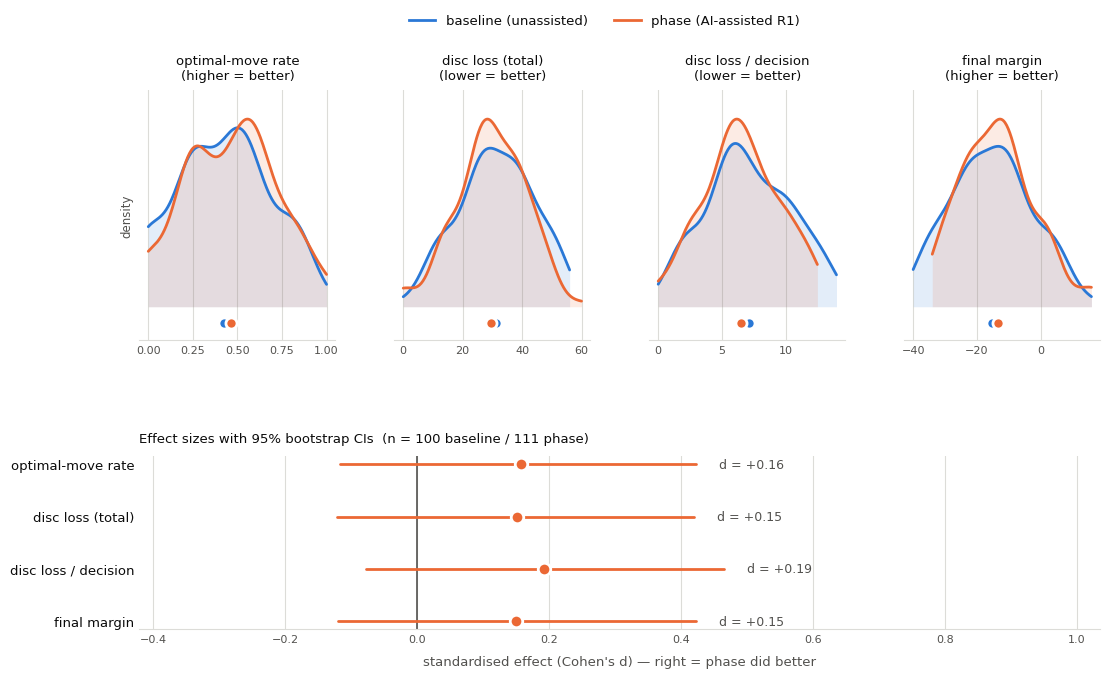


metric                    baseline     phase       d             95% CI
optimal-move rate             0.42      0.46   +0.16   [-0.12, +0.42]
disc loss (total)            31.30     29.48   +0.15   [-0.12, +0.42]
disc loss / decision          7.12      6.52   +0.19   [-0.08, +0.47]
final margin                -15.30    -13.50   +0.15   [-0.12, +0.42]

d is oriented so positive = phase better. margin and disc_loss_total are
the same measurement (r = -0.996) -- not independent evidence.


In [473]:
# Metric comparison: distributions (top) + standardised effects (bottom).
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde

# Categorical slots 1-2 from the validated palette; ink colours for all text.
C_BASE, C_PHASE = "#2a78d6", "#eb6834"
INK, INK_2, GRID = "#0b0b0b", "#52514e", "#dcdcd8"

_mets = [m for m in METRICS if block_values("baseline", m[0]) and block_values("phase", m[0])]
n_m = len(_mets)

fig = plt.figure(figsize=(3.1 * n_m, 7.0))
gs = fig.add_gridspec(2, n_m, height_ratios=[1.45, 1.0], hspace=0.55, wspace=0.30)

# ---------------------------------------------------------------- top: distributions
for j, (key, lab, better) in enumerate(_mets):
    ax = fig.add_subplot(gs[0, j])
    series = {}
    for arm, colour in (("baseline", C_BASE), ("phase", C_PHASE)):
        v = np.asarray([x for x in block_values(arm, key) if x is not None], float)
        series[arm] = v
        if len(v) < 3 or v.std() == 0:
            continue
        grid = np.linspace(v.min(), v.max(), 200)
        dens = gaussian_kde(v)(grid)
        ax.fill_between(grid, dens, color=colour, alpha=0.13, linewidth=0)
        ax.plot(grid, dens, color=colour, linewidth=2, solid_capstyle="round")
    top = ax.get_ylim()[1]
    for arm, colour in (("baseline", C_BASE), ("phase", C_PHASE)):
        v = series[arm]
        if len(v):
            # mean marker sits on its own lane under the curves, with a surface ring
            ax.plot([v.mean()], [-top * 0.085], marker="o", markersize=8, color=colour,
                    markeredgecolor="white", markeredgewidth=2, clip_on=False, zorder=5)
    ax.set_ylim(-top * 0.17, top * 1.10)
    ax.set_title(f"{lab}\n({better} = better)", fontsize=9.5, color=INK, pad=8)
    ax.set_yticks([])
    ax.tick_params(axis="x", labelsize=8, colors=INK_2, length=0)
    ax.grid(axis="x", color=GRID, linewidth=0.8, linestyle="-")
    ax.set_axisbelow(True)
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(GRID)
    ax.spines["bottom"].set_linewidth(0.8)
    if j == 0:
        ax.set_ylabel("density", fontsize=8.5, color=INK_2)

fig.legend(handles=[Line2D([], [], color=C_BASE, lw=2, label="baseline (unassisted)"),
                    Line2D([], [], color=C_PHASE, lw=2, label="phase (AI-assisted R1)")],
           loc="upper center", bbox_to_anchor=(0.5, 1.005), ncol=2,
           frameon=False, fontsize=9.5, labelcolor=INK)

# ------------------------------------------------------- bottom: standardised effects
axf = fig.add_subplot(gs[1, :])
rows = []
for key, lab, better in _mets:
    a = np.asarray([x for x in block_values("baseline", key) if x is not None], float)
    b = np.asarray([x for x in block_values("phase", key) if x is not None], float)
    sd = np.sqrt((a.var(ddof=1) * (len(a) - 1) + b.var(ddof=1) * (len(b) - 1))
                 / (len(a) + len(b) - 2))
    sign = 1.0 if better == "higher" else -1.0        # orient: positive = phase better
    d = sign * (b.mean() - a.mean()) / sd
    boot = np.empty(10000)
    for i in range(10000):
        ra = a[rng.integers(0, len(a), len(a))]
        rb = b[rng.integers(0, len(b), len(b))]
        boot[i] = sign * (rb.mean() - ra.mean()) / sd
    lo, hi = np.percentile(boot, [2.5, 97.5])
    rows.append((lab, d, lo, hi, len(a), len(b)))

ys = np.arange(len(rows))[::-1]
axf.axvline(0, color=INK_2, linewidth=1.2, zorder=1)
for y, (lab, d, lo, hi, na, nb) in zip(ys, rows):
    axf.plot([lo, hi], [y, y], color=C_PHASE, linewidth=2, solid_capstyle="round", zorder=2)
    axf.plot([d], [y], marker="o", markersize=9, color=C_PHASE,
             markeredgecolor="white", markeredgewidth=2, zorder=3)
    axf.text(hi + 0.035, y, f"d = {d:+.2f}", va="center", fontsize=9, color=INK_2)
axf.set_yticks(ys)
axf.set_yticklabels([r[0] for r in rows], fontsize=9.5, color=INK)
axf.set_xlabel("standardised effect (Cohen's d) — right = phase did better",
               fontsize=9.5, color=INK_2, labelpad=8)
axf.tick_params(axis="x", labelsize=8, colors=INK_2, length=0)
axf.tick_params(axis="y", length=0)
axf.grid(axis="x", color=GRID, linewidth=0.8, linestyle="-")
axf.set_axisbelow(True)
for s in ("top", "right", "left"):
    axf.spines[s].set_visible(False)
axf.spines["bottom"].set_color(GRID)
axf.spines["bottom"].set_linewidth(0.8)
pad = 0.30
axf.set_xlim(min(r[2] for r in rows) - pad, max(r[3] for r in rows) + pad * 1.9)
axf.set_title(f"Effect sizes with 95% bootstrap CIs  (n = {rows[0][4]} baseline / {rows[0][5]} phase)",
              fontsize=9.5, color=INK, pad=10, loc="left")

plt.show()

# The table view, so identity and value are never carried by the figure alone.
print(f"\n{'metric':24s} {'baseline':>9s} {'phase':>9s} {'d':>7s} {'95% CI':>18s}")
for (lab, d, lo, hi, na, nb), (key, _, better) in zip(rows, _mets):
    a = np.mean([x for x in block_values("baseline", key) if x is not None])
    b = np.mean([x for x in block_values("phase", key) if x is not None])
    print(f"{lab:24s} {a:9.2f} {b:9.2f} {d:+7.2f}   [{lo:+.2f}, {hi:+.2f}]")
print(f"\nd is oriented so positive = phase better. margin and disc_loss_total are")
print("the same measurement (r = -0.996) -- not independent evidence.")

## Decisions offered, and where play deviates

Two things this section establishes:

1. **How many decisions each round offers, per arm.** This is *not* fixed by the puzzle. The
   number of Black decisions depends on the line played, so it can differ between arms.
2. **Which decision position the arms differ at.** The pooled optimal rate hides this: an arm
   can win on the opening move and be identical afterwards.

In the `moves` column, `!` marks a **suboptimal** move (see `score_from_logs.py`). A token
*without* `!` is optimal.


In [474]:
# Decisions offered per round, per arm.
from scipy.stats import fisher_exact

print("=== decisions offered per round ===")
for rl in (R1_L, R2_L, R3_L):
    counts = {}
    for arm in ARMS:
        v = [int(_num(SCORES[arm][p][rl]["decisions"]))
             for p in ASET[arm] if rl in SCORES[arm][p]]
        counts[arm] = v
        print(f"  {arm:9s} {rl}  n={len(v):3d}  mean={np.mean(v):.2f}  "
              f"dist={dict(sorted(Counter(v).items()))}")
    a, b = counts["baseline"], counts["phase"]
    ks = sorted(set(a) | set(b))
    tab = np.array([[Counter(a)[k] for k in ks], [Counter(b)[k] for k in ks]])
    tab = tab[:, tab.sum(axis=0) > 0]
    chi2, p, _, _ = chi2_contingency(tab)
    _, pu = mannwhitneyu(b, a, alternative="two-sided")
    flag = "  <-- differs" if min(p, pu) < 0.05 else ""
    print(f"    diff={np.mean(b) - np.mean(a):+.3f}  chi2 p={p:.4f}  MW p={pu:.4f}{flag}\n")

=== decisions offered per round ===
  baseline  R1  n=100  mean=3.75  dist={2: 1, 3: 37, 4: 48, 5: 14}
  phase     R1  n=110  mean=4.33  dist={1: 2, 2: 2, 3: 25, 4: 33, 5: 25, 6: 23}
    diff=+0.577  chi2 p=0.0000  MW p=0.0001  <-- differs

  baseline  R2  n=100  mean=2.25  dist={2: 75, 3: 25}
  phase     R2  n=111  mean=2.25  dist={1: 2, 2: 79, 3: 30}
    diff=+0.002  chi2 p=0.3697  MW p=0.9136

  baseline  R3  n=100  mean=2.38  dist={2: 62, 3: 38}
  phase     R3  n=111  mean=2.53  dist={2: 52, 3: 59}
    diff=+0.152  chi2 p=0.0387  MW p=0.0279  <-- differs



In [475]:
# Is `decisions` an outcome of how you played, or a property of the puzzle?
# If the optimal opener is what extends the game, then `decisions` is downstream of
# performance. Stratifying on it would then be conditioning on a mediator, which
# blocks the causal path and biases the arm effect toward zero.

def moves_of(arm, pid, rl):
    return SCORES[arm][pid][rl]["moves"].split()


def is_optimal(tok):
    return not tok.endswith("!")          # '!' marks SUBOPTIMAL


print("=== does the opener decide how many decisions you get? ===")
for rl in (R2_L, R3_L):
    tab = defaultdict(Counter)
    for arm in ARMS:
        for p in ASET[arm]:
            t = moves_of(arm, p, rl)
            tab[len(t)][is_optimal(t[0])] += 1
    print(f"\n {rl} (arms pooled)")
    for nd in sorted(tab):
        tot = sum(tab[nd].values())
        print(f"   {nd} decisions  n={tot:3d}  first move optimal = "
              f"{tab[nd][True]:3d}/{tot:3d} = {tab[nd][True]/tot:.3f}")
    ks = sorted(tab)
    if len(ks) >= 2:
        m = np.array([[tab[k][True], tab[k][False]] for k in ks])
        _, p, _, _ = chi2_contingency(m)
        print(f"   chi2 p={p:.5f}")
        if p < 0.05:
            print("   -> decisions is downstream of play. Do NOT stratify on it;")
            print("      the unstratified arm contrast is the correct total effect.")

=== does the opener decide how many decisions you get? ===

 R2 (arms pooled)
   1 decisions  n=  2  first move optimal =   0/  2 = 0.000
   2 decisions  n=154  first move optimal =  36/154 = 0.234
   3 decisions  n= 55  first move optimal =  54/ 55 = 0.982
   chi2 p=0.00000
   -> decisions is downstream of play. Do NOT stratify on it;
      the unstratified arm contrast is the correct total effect.

 R3 (arms pooled)
   2 decisions  n=114  first move optimal =   0/114 = 0.000
   3 decisions  n= 97  first move optimal =  91/ 97 = 0.938
   chi2 p=0.00000
   -> decisions is downstream of play. Do NOT stratify on it;
      the unstratified arm contrast is the correct total effect.


In [476]:
# Optimal rate by decision position, per arm.
print("=== optimal rate by decision position ===")
for rl in (R2_L, R3_L):
    print(f"\n {rl}")
    maxlen = max(len(moves_of(a, p, rl)) for a in ARMS for p in ASET[a])
    for k in range(maxlen):
        cells = {arm: [is_optimal(moves_of(arm, p, rl)[k])
                       for p in ASET[arm] if len(moves_of(arm, p, rl)) > k]
                 for arm in ARMS}
        a, b = cells["baseline"], cells["phase"]
        if len(a) < 5 or len(b) < 5:
            print(f"   move {k+1}: n={len(a)}/{len(b)}  too small")
            continue
        _, pf = fisher_exact([[sum(a), len(a) - sum(a)], [sum(b), len(b) - sum(b)]])
        star = "  *" if pf < 0.05 else ""
        print(f"   move {k+1}:  base {sum(a):3d}/{len(a):3d} = {np.mean(a):.3f}   "
              f"phase {sum(b):3d}/{len(b):3d} = {np.mean(b):.3f}   Fisher p={pf:.4f}{star}")

print("\n=== first deviation from the optimal line (0 = played it perfectly) ===")
for rl in (R2_L, R3_L):
    print(f"\n {rl}")
    for arm in ARMS:
        fd = []
        for p in ASET[arm]:
            t = moves_of(arm, p, rl)
            fd.append(next((i + 1 for i, x in enumerate(t) if not is_optimal(x)), 0))
        c, n = Counter(fd), len(fd)
        lab = {0: "perfect"}
        print(f"   {arm:9s} " + "  ".join(
            f"{lab.get(k, 'move ' + str(k))}={c[k]:3d} ({c[k]/n*100:4.1f}%)" for k in sorted(c)))

print("\n=== opener_optimal (the column score_from_logs.py already writes) ===")
for rl in (R2_L, R3_L):
    a = [SCORES["baseline"][p][rl]["opener_optimal"] == "True" for p in ASET["baseline"]]
    b = [SCORES["phase"][p][rl]["opener_optimal"] == "True" for p in ASET["phase"]]
    _, pf = fisher_exact([[sum(a), len(a) - sum(a)], [sum(b), len(b) - sum(b)]])
    orr = (sum(b) / (len(b) - sum(b))) / (sum(a) / (len(a) - sum(a)))
    star = "  *" if pf < 0.05 else ""
    print(f"  {rl}: base={np.mean(a):.3f}  phase={np.mean(b):.3f}  "
          f"OR={orr:.2f}  Fisher p={pf:.4f}{star}")

=== optimal rate by decision position ===

 R2
   move 1:  base  43/100 = 0.430   phase  47/111 = 0.423   Fisher p=1.0000
   move 2:  base  61/100 = 0.610   phase  66/109 = 0.606   Fisher p=1.0000
   move 3:  base  10/ 25 = 0.400   phase  12/ 30 = 0.400   Fisher p=1.0000

 R3
   move 1:  base  34/100 = 0.340   phase  57/111 = 0.514   Fisher p=0.0125  *
   move 2:  base  36/100 = 0.360   phase  41/111 = 0.369   Fisher p=1.0000
   move 3:  base  25/ 38 = 0.658   phase  39/ 59 = 0.661   Fisher p=1.0000

=== first deviation from the optimal line (0 = played it perfectly) ===

 R2
   baseline  perfect= 10 (10.0%)  move 1= 57 (57.0%)  move 2= 18 (18.0%)  move 3= 15 (15.0%)
   phase     perfect= 13 (11.7%)  move 1= 64 (57.7%)  move 2= 17 (15.3%)  move 3= 17 (15.3%)

 R3
   baseline  perfect= 10 (10.0%)  move 1= 66 (66.0%)  move 2= 23 (23.0%)  move 3=  1 ( 1.0%)
   phase     perfect= 20 (18.0%)  move 1= 54 (48.6%)  move 2= 37 (33.3%)

=== opener_optimal (the column score_from_logs.py already w

### How to read the position results

The arms differ at the **opening move of R3** and nowhere else. Five of the six cells return
p = 1.000. Frozen sample: n = 100 baseline / 111 phase (`scores_frozen_20260811.csv`).

    R3 move 1   0.340 -> 0.514   p = 0.0125
    all others  no difference    p = 1.0000

**The two rounds genuinely differ.** A round x arm interaction on opener optimality
(cluster-robust logistic, clustered on participant) gives beta = +0.744, se = 0.342,
p = 0.0296. So R2 and R3 are not interchangeable, and pooling them is not the right default:
aggregating drops the odds ratio from 2.05 (R3 alone) to 1.41 (pooled, p = 0.119), because R2
contributes an odds ratio of 0.97 rather than a weak signal.

Caveats, in order of how much they matter:

1. **This was found by searching six cells** (3 positions x 2 rounds). Bonferroni and
   Benjamini-Hochberg both put the smallest adjusted p at **0.0749**. As a sweep, it does not
   survive correction. Report the whole grid, not the winning cell.
2. **The round difference is real but unexplained.** `games/othello/motif_analysis.py` shows
   R2 (`b220260706`, answer g7) and R3 (`bg20260726`, answer b2) are closely matched: both
   answers are X-squares, both have 16 greedy alternatives, both offer 3 decisions, worst case
   -15 vs -14. Pooled opener difficulty is also the same (0.427 vs 0.431). So the R2/R3 split
   is not a difficulty or motif effect, and we cannot say what it is.
3. **Round order is confounded with puzzle identity.** R2 always precedes R3, so "transfer
   appears only on the second transfer puzzle" and "transfer appears only on bg20260726" are
   indistinguishable here. Counterbalance in any follow-up.
4. **`opener_optimal` is a pre-existing column** in `scores.csv`, written by
   `score_from_logs.py` before this analysis existed. That is an argument for treating the
   opener as a designated test rather than a fished one, but it is not pre-registration.
5. **Two items is not a test.** r(R2 opener, R3 opener) = 0.274, Spearman-Brown = 0.431. That
   is normal for two single binary items and is the main limit on any individual-difference
   claim here.
6. `solved` (perfect play) is close to a restatement of the opener result, because missing the
   opener makes perfect play impossible. It is not independent evidence.

Treat this as **exploratory**. It is the hypothesis for a pre-registered replication, not a
confirmatory result from this sample.


## Figures

Three figures, each carrying something the others do not.

1. **The full sweep.** Every position x round test on one axis with CIs. A single
   significant cell is only interpretable against the cells that were also run.
2. **The mechanism.** The opener shifts between arms, and the opener is worth about
   seven discs of final margin. That pair is why margin moves at all.
3. **Effect sizes on a common axis.** All outcomes standardised, oriented so right =
   assisted did better, with the mechanically-linked chain separated from the
   independent signal.

Palette is the notebook's existing blue/orange, validated: normal-vision dE = 33.6,
worst-case CVD dE = 24.5 (deuteranopia 31.6 / protanopia 24.5 / tritanopia 45.1),
both above the >= 15 and >= 8 floors.

For final figures, point `load_scores` at `scores_frozen_20260811.csv` so the plots
match the frozen n = 100 / 111.


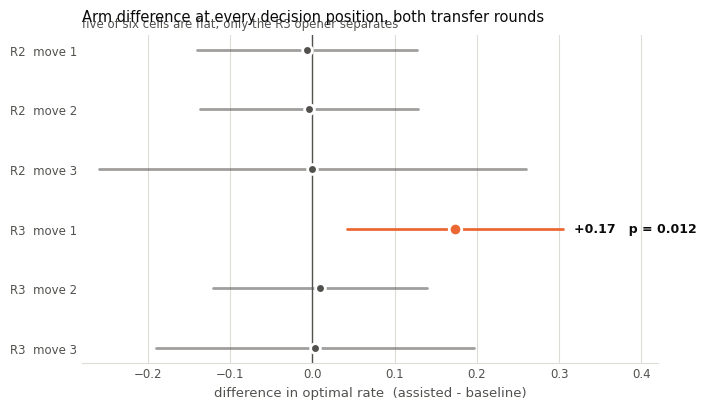

In [477]:
# Figure 1 -- the full position x round sweep.
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

C_BASE, C_PHASE = "#2a78d6", "#eb6834"
INK, INK_2, GRID = "#0b0b0b", "#52514e", "#dcdcd8"


def _prop_diff_ci(a, b):
    """phase - baseline, with a normal-approximation 95% CI."""
    pa, pb = np.mean(a), np.mean(b)
    se = np.sqrt(pa * (1 - pa) / len(a) + pb * (1 - pb) / len(b))
    return pb - pa, (pb - pa) - 1.96 * se, (pb - pa) + 1.96 * se


cells = []
for rl in (R2_L, R3_L):
    maxlen = max(len(moves_of(a, p, rl)) for a in ARMS for p in ASET[a])
    for k in range(maxlen):
        vals = {arm: [is_optimal(moves_of(arm, p, rl)[k])
                      for p in ASET[arm] if len(moves_of(arm, p, rl)) > k]
                for arm in ARMS}
        a, b = vals["baseline"], vals["phase"]
        if len(a) < 5 or len(b) < 5:
            continue
        _, pf = fisher_exact([[sum(a), len(a) - sum(a)], [sum(b), len(b) - sum(b)]])
        d, lo, hi = _prop_diff_ci(a, b)
        cells.append((rl, k + 1, d, lo, hi, pf, len(a), len(b)))

fig, ax = plt.subplots(figsize=(7.2, 4.2))
ys = np.arange(len(cells))[::-1]
for y, (rl, pos, d, lo, hi, pf, na, nb) in zip(ys, cells):
    sig = pf < 0.05
    col = C_PHASE if sig else INK_2
    ax.plot([lo, hi], [y, y], color=col, linewidth=2, solid_capstyle="round",
            alpha=1.0 if sig else 0.55)
    ax.plot([d], [y], marker="o", markersize=9 if sig else 7, color=col,
            markeredgecolor="white", markeredgewidth=2, zorder=5)

ax.axvline(0, color=INK_2, linewidth=1)
ax.set_yticks(ys)
ax.set_yticklabels([f"{rl}  move {pos}" for rl, pos, *_ in cells], fontsize=9, color=INK)
ax.set_xlabel("difference in optimal rate  (assisted - baseline)", fontsize=9.5, color=INK_2)
ax.grid(axis="x", color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color(GRID)
ax.tick_params(colors=INK_2, length=0, labelsize=8.5)

# selective direct label: only the cell that separates
for y, (rl, pos, d, lo, hi, pf, na, nb) in zip(ys, cells):
    if pf < 0.05:
        ax.annotate(f"+{d:.2f}   p = {pf:.3f}", xy=(hi, y), xytext=(8, 0),
                    textcoords="offset points", va="center", fontsize=9,
                    color=INK, fontweight="bold")

ax.set_title("Arm difference at every decision position, both transfer rounds",
             fontsize=10.5, color=INK, pad=10, loc="left")
ax.text(0, 1.015, "five of six cells are flat; only the R3 opener separates",
        transform=ax.transAxes, fontsize=8.5, color=INK_2, va="bottom")
ax.set_xlim(-0.28, 0.42)
plt.tight_layout()
plt.show()

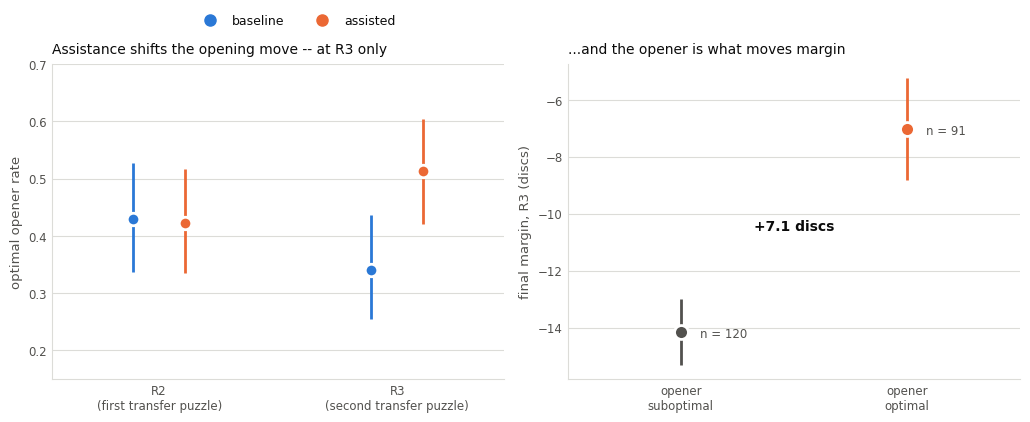

In [478]:
# Figure 2 -- the mechanism: arm shifts the opener, the opener drives margin.
fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.0))

# ---- (a) opener rate by round x arm, with Wilson CIs
def _wilson(k, n, z=1.96):
    if n == 0:
        return 0.0, 0.0, 0.0
    p = k / n
    den = 1 + z**2 / n
    c = (p + z**2 / (2 * n)) / den
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / den
    return p, max(c - half, 0), min(c + half, 1)


ax = axes[0]
xs = np.array([0.0, 1.0])
for arm, col, off in (("baseline", C_BASE, -0.11), ("phase", C_PHASE, +0.11)):
    ms, los, his = [], [], []
    for rl in (R2_L, R3_L):
        v = [SCORES[arm][p][rl]["opener_optimal"] == "True" for p in ASET[arm]]
        m, lo, hi = _wilson(sum(v), len(v))
        ms.append(m); los.append(m - lo); his.append(hi - m)
    ax.errorbar(xs + off, ms, yerr=[los, his], fmt="o", markersize=9, color=col,
                markeredgecolor="white", markeredgewidth=2, capsize=0,
                elinewidth=2, zorder=5)
ax.set_xticks(xs)
ax.set_xticklabels(["R2\n(first transfer puzzle)", "R3\n(second transfer puzzle)"], fontsize=9)
ax.set_ylabel("optimal opener rate", fontsize=9.5, color=INK_2)
ax.set_ylim(0.15, 0.70)
ax.set_xlim(-0.45, 1.45)
ax.set_title("Assistance shifts the opening move -- at R3 only", fontsize=10, color=INK, loc="left", pad=8)

# ---- (b) final margin by opener status (arms pooled)
ax2 = axes[1]
groups = []
for opt_ in (False, True):
    v = [round_value(arm, p, R3_L, "margin") for arm in ARMS for p in ASET[arm]
         if (SCORES[arm][p][R3_L]["opener_optimal"] == "True") is opt_
         and round_value(arm, p, R3_L, "margin") is not None]
    groups.append(np.asarray(v, float))
for i, (v, lab) in enumerate(zip(groups, ["opener\nsuboptimal", "opener\noptimal"])):
    se = v.std(ddof=1) / np.sqrt(len(v))
    ax2.errorbar([i], [v.mean()], yerr=[1.96 * se], fmt="o", markersize=10,
                 color=INK_2 if i == 0 else C_PHASE, markeredgecolor="white",
                 markeredgewidth=2, elinewidth=2, capsize=0, zorder=5)
    ax2.annotate(f"n = {len(v)}", xy=(i, v.mean()), xytext=(14, -4),
                 textcoords="offset points", fontsize=8.5, color=INK_2)
gap = groups[1].mean() - groups[0].mean()
ax2.annotate(f"{gap:+.1f} discs", xy=(0.5, np.mean([g.mean() for g in groups])),
             ha="center", fontsize=10, color=INK, fontweight="bold")
ax2.set_xticks([0, 1])
ax2.set_xticklabels(["opener\nsuboptimal", "opener\noptimal"], fontsize=9)
ax2.set_xlim(-0.5, 1.5)
ax2.set_ylabel("final margin, R3 (discs)", fontsize=9.5, color=INK_2)
ax2.set_title("...and the opener is what moves margin", fontsize=10, color=INK, loc="left", pad=8)

for a in (ax, ax2):
    a.grid(axis="y", color=GRID, linewidth=0.8)
    a.set_axisbelow(True)
    for s in ("top", "right"):
        a.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        a.spines[s].set_color(GRID)
    a.tick_params(colors=INK_2, length=0, labelsize=8.5)

fig.legend(handles=[Line2D([], [], color=C_BASE, marker="o", lw=0, markersize=8, label="baseline"),
                    Line2D([], [], color=C_PHASE, marker="o", lw=0, markersize=8, label="assisted")],
           loc="upper center", bbox_to_anchor=(0.29, 1.06), ncol=2, frameon=False,
           fontsize=9, labelcolor=INK)
plt.tight_layout()
plt.show()

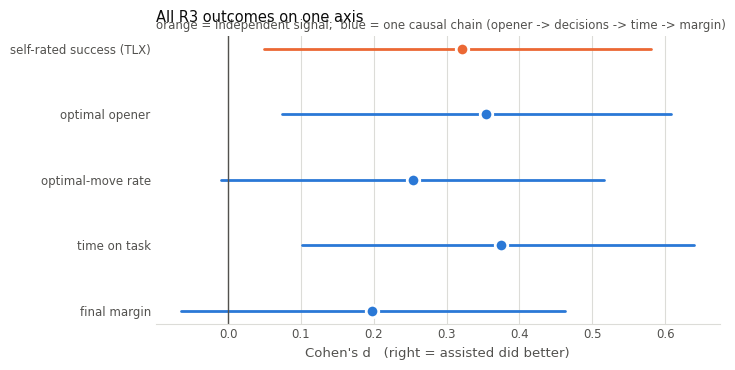

Effect sizes, R3:
  self-rated success (TLX)   d = +0.320  [+0.049, +0.581]   (independent)
  optimal opener             d = +0.354  [+0.074, +0.607]   (chain)
  optimal-move rate          d = +0.254  [-0.010, +0.516]   (chain)
  time on task               d = +0.374  [+0.101, +0.640]   (chain)
  final margin               d = +0.198  [-0.064, +0.463]   (chain)


In [479]:
# Figure 3 -- every outcome on one standardised axis (R3, the clean round).
def _d_ci(a, b, nboot=4000, seed=11):
    a, b = np.asarray(a, float), np.asarray(b, float)
    sd = np.sqrt(((len(a) - 1) * a.var(ddof=1) + (len(b) - 1) * b.var(ddof=1))
                 / (len(a) + len(b) - 2))
    d = (b.mean() - a.mean()) / sd
    r = np.random.default_rng(seed)
    bs = [(r.choice(b, len(b)).mean() - r.choice(a, len(a)).mean()) / sd for _ in range(nboot)]
    lo, hi = np.percentile(bs, [2.5, 97.5])
    return d, lo, hi


def _pair(fn):
    return ([fn("baseline", p) for p in ASET["baseline"]],
            [fn("phase", p) for p in ASET["phase"]])


rows = []
a, b = tlx_values("baseline", "R3", "performance"), tlx_values("phase", "R3", "performance")
rows.append(("self-rated success (TLX)", *_d_ci(a, b), "independent"))
a, b = _pair(lambda ar, p: float(SCORES[ar][p][R3_L]["opener_optimal"] == "True"))
rows.append(("optimal opener", *_d_ci(a, b), "chain"))
a, b = _pair(lambda ar, p: round_value(ar, p, R3_L, "optimal_rate"))
rows.append(("optimal-move rate", *_d_ci(a, b), "chain"))
a, b = _pair(lambda ar, p: _num(SCORES[ar][p][R3_L]["seconds"]))
rows.append(("time on task", *_d_ci(a, b), "chain"))
a, b = _pair(lambda ar, p: round_value(ar, p, R3_L, "margin"))
a = [x for x in a if x is not None]; b = [x for x in b if x is not None]
rows.append(("final margin", *_d_ci(a, b), "chain"))

fig, ax = plt.subplots(figsize=(7.4, 3.8))
ys = np.arange(len(rows))[::-1]
for y, (lab, d, lo, hi, kind) in zip(ys, rows):
    col = C_PHASE if kind == "independent" else C_BASE
    ax.plot([lo, hi], [y, y], color=col, linewidth=2, solid_capstyle="round")
    ax.plot([d], [y], marker="o", markersize=9, color=col,
            markeredgecolor="white", markeredgewidth=2, zorder=5)
ax.axvline(0, color=INK_2, linewidth=1)
ax.set_yticks(ys)
ax.set_yticklabels([r[0] for r in rows], fontsize=9, color=INK)
ax.set_xlabel("Cohen's d   (right = assisted did better)", fontsize=9.5, color=INK_2)
ax.grid(axis="x", color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color(GRID)
ax.tick_params(colors=INK_2, length=0, labelsize=8.5)
ax.set_title("All R3 outcomes on one axis", fontsize=10.5, color=INK, pad=10, loc="left")
ax.text(0, 1.015,
        "orange = independent signal;  blue = one causal chain (opener -> decisions -> time -> margin)",
        transform=ax.transAxes, fontsize=8.5, color=INK_2, va="bottom")
plt.tight_layout()
plt.show()

print("Effect sizes, R3:")
for lab, d, lo, hi, kind in rows:
    print(f"  {lab:26s} d = {d:+.3f}  [{lo:+.3f}, {hi:+.3f}]   ({kind})")